# Melbourne auction clearance - first look

Trying to predict whether a property sells at auction. Data is the VIC auction
results export + BOM weather + PTV stations.

TODO: figure out what features actually matter
TODO: try xgboost?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('/Users/kanav/projects/melbourne-auction-clearance/data/raw/vic_auction_results.csv')
df.shape

FileNotFoundError: [Errno 2] No such file or directory: '/Users/kanav/projects/melbourne-auction-clearance/data/raw/vic_auction_results.csv'

hmm that path breaks on the lab machines, use relative for now

In [3]:
df = pd.read_csv('../data/raw/vic_auction_results.csv')
print(df.shape)
df.head()

(48712, 25)


,listing_id,auction_date,suburb,council_area,region_name,lat,lon,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,building_area_sqm,year_built,agency,price_guide,rba_cash_rate,n_scheduled,result_code,result_description,sold_price,price_per_sqm,vendor_discount_pct,days_to_settle,sale_settlement_date
0,VIC2007372,2019-11-23,Hawthorn,Boroondara,Inner East,-37.815570,145.032524,u,1,1,0,72.1,81.1,1978,Harcourts,"$829,000 - $907,000",0.75,255,PI,Passed in,NaN,NaN,NaN,NaN,NaN
1,VIC2029783,2020-07-25,Ivanhoe,Banyule,Northern Metropolitan,-37.775434,145.044330,h,3,2,1,365.1,172.1,2020,Barry Plant,"$1,417,000 - $1,550,000",0.25,169,PI,Passed in,NaN,NaN,NaN,NaN,NaN
2,VIC2025055,2021-06-26,Point Cook,Wyndham,Western Metropolitan,-37.901306,144.742322,u,1,2,1,38.7,88.4,1990,Woodards,"$400,000 - $438,000",0.10,161,S,Sold at auction,439000,4966.0,1.51,60.0,2021-08-25
3,VIC2038592,2019-02-02,Narre Warren,Casey,South-Eastern Metropolitan,-38.020004,145.291473,h,2,2,1,261.3,104.0,1976,Jellis Craig,"$557,000 - $609,000",1.50,153,S,Sold at auction,"$632,000",6077.0,0.36,60.0,2019-04-03
4,VIC2039322,2021-08-28,Flemington,Melbourne,Western Metropolitan,-37.770309,144.935366,h,3,2,3,908.6,93.3,1949,Stockdale & Leggo,"$897,000 - $981,000",0.10,168,S,Sold at auction,"$1,220,000",13076.0,10.22,45.0,2021-10-12


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48712 entries, 0 to 48711
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   listing_id            48712 non-null  str    
 1   auction_date          48712 non-null  str    
 2   suburb                48712 non-null  str    
 3   council_area          48712 non-null  str    
 4   region_name           48712 non-null  str    
 5   lat                   48712 non-null  float64
 6   lon                   48712 non-null  float64
 7   property_type         48712 non-null  str    
 8   bedrooms              48712 non-null  int64  
 9   bathrooms             48712 non-null  int64  
 10  car_spaces            48712 non-null  int64  
 11  land_size_sqm         48712 non-null  float64
 12  building_area_sqm     48712 non-null  float64
 13  year_built            48712 non-null  int64  
 14  agency                48712 non-null  str    
 15  price_guide           48712 no

In [5]:
df.describe()

,lat,lon,bedrooms,bathrooms,car_spaces,land_size_sqm,building_area_sqm,year_built,rba_cash_rate,n_scheduled,price_per_sqm,vendor_discount_pct,days_to_settle
count,48712.000000,48712.000000,48712.000000,48712.000000,48712.000000,48712.000000,48712.000000,48712.000000,48712.000000,48712.000000,32472.000000,32472.000000,32472.000000
mean,-37.839333,145.027156,2.384217,1.460112,1.007206,364.926782,125.383848,1967.151031,1.993903,192.684759,11700.993718,3.831298,56.652347
std,0.083545,0.112053,1.028898,0.621917,0.901215,317.053916,52.869043,27.281995,1.758112,53.255848,6245.202744,5.728317,19.029103
min,-38.177692,144.558720,1.000000,1.000000,0.000000,0.200000,35.000000,1880.000000,0.100000,8.000000,2163.000000,-18.330000,30.000000
25%,-37.879758,144.960040,2.000000,1.000000,0.000000,105.900000,81.600000,1949.000000,0.100000,160.000000,7086.750000,-0.130000,45.000000
50%,-37.834850,145.012817,2.000000,1.000000,1.000000,270.400000,117.100000,1967.000000,1.500000,189.000000,10294.000000,3.675000,60.000000
75%,-37.787110,145.081889,3.000000,2.000000,2.000000,547.800000,163.600000,1986.000000,4.100000,235.000000,14711.000000,7.610000,60.000000
max,-37.567933,145.509657,7.000000,4.000000,4.000000,2200.000000,357.100000,2024.000000,4.350000,288.000000,56543.000000,29.420000,90.000000


## what do the result codes look like

In [6]:
df['result_code'].value_counts()

result_code
S     27901
PI    11357
VB     3221
SP     2621
SA     1950
W      1662
Name: count, dtype: int64

In [7]:
# S = sold, SP = sold prior, SA = sold after, PI = passed in, VB = vendor bid, W = withdrawn
# so sold = S, SP, SA
df['sold'] = df['result_code'].isin(['S','SP','SA']).astype(int)
df['sold'].mean()

np.float64(0.6666119231400887)

67% clearance. sounds about right for melbourne

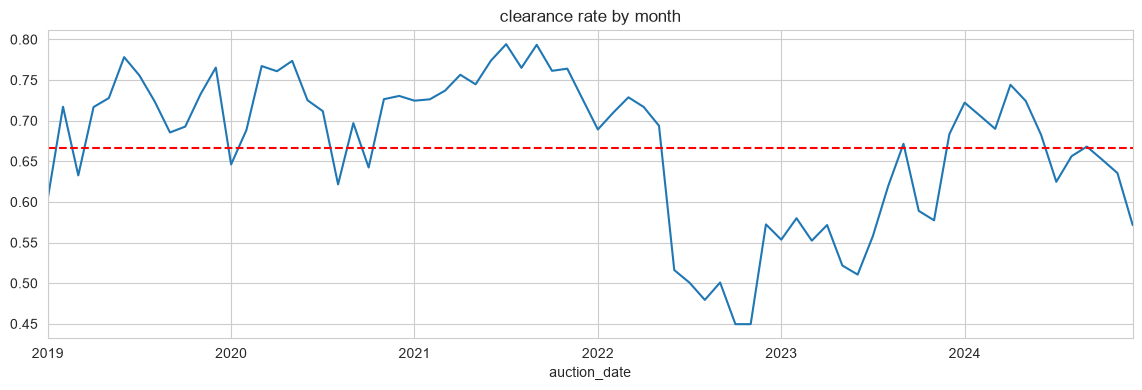

In [8]:
df['auction_date'] = pd.to_datetime(df['auction_date'])
monthly = df.groupby(df['auction_date'].dt.to_period('M'))['sold'].mean()
monthly.plot(figsize=(14,4), title='clearance rate by month')
plt.axhline(df['sold'].mean(), color='red', ls='--')
plt.show()

ok so there's a massive drop in 2022. that's the RBA rate rises.
also a hole in 2020 - covid lockdowns, auctions were banned onsite

In [9]:
df['suburb'].nunique()

297

297?? there are not 297 suburbs in this dataset

In [10]:
sorted(df['suburb'].unique())[:20]

[' Airport West',
 ' Albert Park',
 ' Altona',
 ' Armadale',
 ' Ascot Vale',
 ' Balwyn',
 ' Bayswater',
 ' Beaumaris',
 ' Bentleigh',
 ' Berwick',
 ' Blackburn',
 ' Boronia',
 ' Box Hill',
 ' Brighton',
 ' Brunswick',
 ' Bundoora',
 ' Burwood',
 ' Camberwell',
 ' Carlton',
 ' Carnegie']

right - case and whitespace. deal with it later

In [11]:
df['suburb'] = df['suburb'].str.strip().str.title()
df['suburb'].nunique()

100

In [12]:
df.groupby('suburb')['sold'].agg(['size','mean']).sort_values('size', ascending=False).head(15)

,size,mean
suburb,,
Toorak,881,0.692395
Sandringham,853,0.685815
Port Melbourne,846,0.682033
Fitzroy,844,0.667062
Brighton,836,0.684211
Balwyn,833,0.665066
Kew,827,0.690447
South Melbourne,821,0.700365
Prahran,820,0.700000


## prices

In [13]:
df['sold_price'].head(10)

0           NaN
1           NaN
2        439000
3      $632,000
4    $1,220,000
5       2839000
6        817000
7       2277000
8    $1,310,000
9        586000
Name: sold_price, dtype: str

some have dollar signs some don't. great.

In [14]:
df['sold_price'] = pd.to_numeric(
    df['sold_price'].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False),
    errors='coerce')
df['sold_price'].describe()

count    3.247200e+04
mean     1.362994e+06
std      6.737067e+05
min      2.220000e+05
25%      8.700000e+05
50%      1.192000e+06
75%      1.689000e+06
max      4.757000e+06
Name: sold_price, dtype: float64

In [15]:
df['price_guide'].head()

0        $829,000 - $907,000
1    $1,417,000 - $1,550,000
2        $400,000 - $438,000
3        $557,000 - $609,000
4        $897,000 - $981,000
Name: price_guide, dtype: str

In [16]:
# split the guide range
guide = df['price_guide'].str.split(' - ', expand=True)
for c in [0,1]:
    guide[c] = pd.to_numeric(guide[c].str.replace('$','',regex=False).str.replace(',','',regex=False), errors='coerce')
df['guide_mid'] = (guide[0] + guide[1]) / 2
df['guide_mid'].describe()

count    4.871200e+04
mean     1.226262e+06
std      6.457846e+05
min      1.780000e+05
25%      7.625000e+05
50%      1.068000e+06
75%      1.524500e+06
max      5.181500e+06
Name: guide_mid, dtype: float64

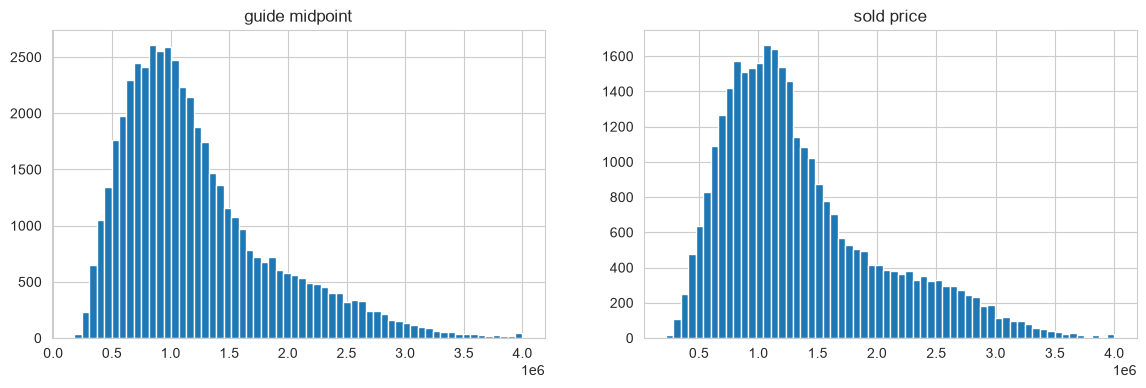

In [17]:
fig, ax = plt.subplots(1,2, figsize=(14,4))
df['guide_mid'].clip(upper=4e6).hist(bins=60, ax=ax[0]); ax[0].set_title('guide midpoint')
df['sold_price'].clip(upper=4e6).hist(bins=60, ax=ax[1]); ax[1].set_title('sold price')
plt.show()

## property type / bedrooms

In [18]:
df.groupby('property_type')['sold'].agg(['size','mean'])

,size,mean
property_type,,
h,25575,0.713705
t,5645,0.683437
u,17492,0.592328


In [19]:
df.groupby('bedrooms')['sold'].agg(['size','mean'])

,size,mean
bedrooms,,
1,10508,0.519414
2,17195,0.667113
3,14017,0.741528
4,5841,0.748502
5,1082,0.688540
6,66,0.484848
7,3,0.000000


3-4 bedrooms clear best. 1br and 6br+ are worse. not linear, interesting

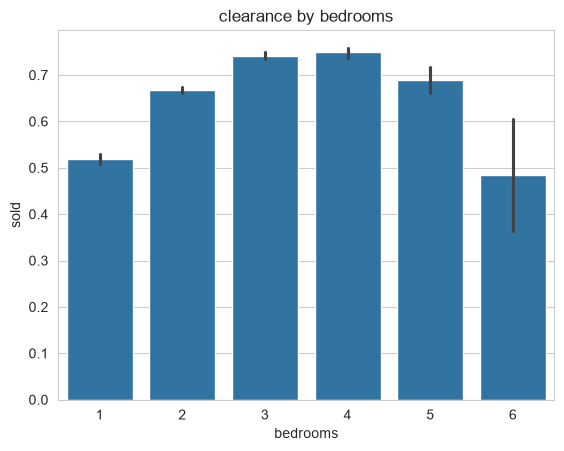

In [20]:
sns.barplot(data=df[df.bedrooms<=6], x='bedrooms', y='sold')
plt.title('clearance by bedrooms')
plt.show()

## missing values

In [21]:
df.isna().sum().sort_values(ascending=False).head(12)

sale_settlement_date    16240
days_to_settle          16240
vendor_discount_pct     16240
price_per_sqm           16240
sold_price              16240
listing_id                  0
agency                      0
sold                        0
result_description          0
result_code                 0
n_scheduled                 0
rba_cash_rate               0
dtype: int64

sold_price / price_per_sqm / days_to_settle etc are missing ~33% which is
about the passed-in rate. makes sense, unsold properties don't have a sale price.

will just impute with median

## first model

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

features = ['bedrooms','bathrooms','car_spaces','land_size_sqm','building_area_sqm',
            'distance_to_cbd_km','guide_mid','rba_cash_rate',
            'sold_price','price_per_sqm','days_to_settle','vendor_discount_pct']

wait, distance_to_cbd_km isn't in the raw data, I need to compute it

In [23]:
CBD_LAT, CBD_LON = -37.8183, 144.9671

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2-lat1)
    dl = np.radians(lon2-lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

df['distance_to_cbd_km'] = df.apply(
    lambda r: haversine(r['lat'], r['lon'], CBD_LAT, CBD_LON), axis=1)
df['distance_to_cbd_km'].describe()

count    48712.000000
mean        11.920047
std          8.618561
min          0.048292
25%          5.560194
50%          9.682870
75%         16.005115
max         55.751112
Name: distance_to_cbd_km, dtype: float64

that took forever. should vectorise it

In [24]:
X = df[features].apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())
y = df['sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(38969, 12) (9743, 12)


In [25]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict_proba(X_test)[:,1]
print('AUC:', roc_auc_score(y_test, pred))

AUC: 1.0


# AUC 1.0

that can't be right.

nobody predicts auctions perfectly. something is wrong.

In [26]:
pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

sold_price             0.332466
price_per_sqm          0.286757
vendor_discount_pct    0.274959
days_to_settle         0.080863
guide_mid              0.009537
bedrooms               0.005552
rba_cash_rate          0.002775
distance_to_cbd_km     0.002417
land_size_sqm          0.002190
building_area_sqm      0.001899
bathrooms              0.000469
car_spaces             0.000117
dtype: float64

sold_price is doing all the work.

...oh. **sold_price only exists if the property sold.** I median-imputed the nulls
so every unsold property got exactly the same value and the model just learned
"price == 863000 means it didn't sell".

I'm predicting the sale price to predict whether there was a sale.

Same problem with price_per_sqm, days_to_settle, vendor_discount_pct - all of
those only exist after a sale happens.

In [27]:
# drop everything that only exists post-sale
safe_features = ['bedrooms','bathrooms','car_spaces','land_size_sqm','building_area_sqm',
                 'distance_to_cbd_km','guide_mid','rba_cash_rate']

X = df[safe_features].apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf2.fit(X_train, y_train)
print('AUC:', roc_auc_score(y_test, rf2.predict_proba(X_test)[:,1]))

AUC: 0.643860161660885


0.63. that's the real number and it's not great.

also I should check - am I even allowed to use a random split here? this is time
series data. if I train on 2024 and test on 2020 that's cheating too.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
lr.fit(X_train, y_train)
print('LR AUC:', roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

LR AUC: 0.6386125183189371


## where I'm up to

- clearance is ~67% overall, crashes in 2022 with the rate rises
- first model was a leak, sold_price gives away the answer
- honest baseline is ~0.63 AUC which is barely better than guessing
- random split is wrong for time series, need a chronological one
- this notebook is a mess and I keep re-reading the CSV with different cleaning
  in different cells

next: pull the loading + cleaning out into proper scripts so it's the same
every time, then look for features that are actually available before the
auction happens